# Dynamax LDS fit for MC Pacman spiking data

Fit one regularized linear Gaussian state-space model per condition. Spikes are the observations; force is held out as an evaluation target decoded from inferred latent states.

## Imports and configuration

In [1]:
from pathlib import Path
import os
import pickle

SCRATCH = Path(os.environ.get("SCRATCH", "/farmshare/user_data/vivek772/stats-305c-data"))
TMP_DIR = SCRATCH / "tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("TMPDIR", str(TMP_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(TMP_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dynamax.linear_gaussian_ssm import LinearGaussianConjugateSSM
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

DATA_PATH = SCRATCH / "mc_pacman.pkl"
BIN_MS = 50
SMOOTH_SIGMA_BINS = 1.0
STATE_DIM = 18
EM_ITERS = 100
TEST_FRACTION = 0.2
SEED = 7
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

print("jax", jax.__version__)
print("data", DATA_PATH)

jax 0.6.2
data /farmshare/user_data/vivek772/stats-305c-data/mc_pacman.pkl


## Data loading and schema validation

In [2]:
def load_data(path):
    path = Path(path)
    with path.open("rb") as f:
        return pickle.load(f)


def validate_schema(data):
    expected_keys = {"condition", "force", "spikes"}
    if not isinstance(data, dict):
        raise TypeError(f"Expected dict, got {type(data).__name__}")
    if set(data) != expected_keys:
        raise KeyError(f"Expected keys {sorted(expected_keys)}, got {sorted(data)}")

    condition = np.asarray(data["condition"])
    force = data["force"]
    spikes = data["spikes"]
    n_trials = len(condition)

    if condition.shape != (362,):
        raise ValueError(f"Expected condition shape (362,), got {condition.shape}")
    if len(force) != n_trials or len(spikes) != n_trials:
        raise ValueError("condition, force, and spikes must have the same trial count")
    if not np.array_equal(np.unique(condition), np.arange(1, 9)):
        raise ValueError(f"Expected condition labels 1..8, got {np.unique(condition)}")

    lengths = []
    for i, (sp, fo) in enumerate(zip(spikes, force)):
        sp = np.asarray(sp)
        fo = np.asarray(fo)
        if sp.ndim != 2 or sp.shape[0] != 128:
            raise ValueError(f"spikes[{i}] expected shape (128, T), got {sp.shape}")
        if fo.ndim != 2 or fo.shape[0] != 1:
            raise ValueError(f"force[{i}] expected shape (1, T), got {fo.shape}")
        if sp.shape[1] != fo.shape[1]:
            raise ValueError(f"trial {i} spike/force length mismatch: {sp.shape[1]} vs {fo.shape[1]}")
        if not np.isin(sp, [0, 1]).all():
            raise ValueError(f"spikes[{i}] contains values outside 0/1")
        lengths.append(sp.shape[1])

    summary = pd.DataFrame({"condition": condition, "length_ms": lengths})
    summary = summary.groupby("condition").agg(n_trials=("length_ms", "size"), length_ms=("length_ms", "first"))
    print(summary)
    return condition, force, spikes, summary


data = load_data(DATA_PATH)
conditions, force_trials, spike_trials, schema_summary = validate_schema(data)

           n_trials  length_ms
condition                     
1                38       6001
2                35       6001
3                38       2251
4                37       2251
5                36       6001
6                43       4001
7                61       3334
8                74       4668


## Preprocessing helpers

In [3]:
def _trim_to_bins(arr, bin_ms):
    n_bins = arr.shape[-1] // bin_ms
    if n_bins < 2:
        raise ValueError(f"trial is too short for {bin_ms} ms bins")
    return arr[..., : n_bins * bin_ms], n_bins


def bin_and_smooth_trials(trials, bin_ms=50, smooth_sigma_bins=1.0, kind="spikes"):
    processed = []
    for trial in trials:
        arr = np.asarray(trial, dtype=float)
        trimmed, n_bins = _trim_to_bins(arr, bin_ms)
        if kind == "spikes":
            binned = trimmed.reshape(arr.shape[0], n_bins, bin_ms).sum(axis=2).T
        elif kind == "force":
            binned = trimmed.reshape(arr.shape[0], n_bins, bin_ms).mean(axis=2).T
        else:
            raise ValueError("kind must be 'spikes' or 'force'")
        if smooth_sigma_bins > 0:
            binned = gaussian_filter1d(binned, sigma=smooth_sigma_bins, axis=0, mode="nearest")
        processed.append(binned.astype(np.float64))
    return processed


def split_condition_trials(condition, cond, test_fraction=0.2, seed=7):
    idx = np.flatnonzero(condition == cond)
    rng = np.random.default_rng(seed + int(cond))
    idx = rng.permutation(idx)
    n_test = max(1, int(round(test_fraction * len(idx))))
    return np.sort(idx[n_test:]), np.sort(idx[:n_test])


def standardize_train_test(train_trials, test_trials, eps=1e-6):
    stacked = np.concatenate(train_trials, axis=0)
    mean = stacked.mean(axis=0)
    std = stacked.std(axis=0)
    std = np.where(std < eps, 1.0, std)
    train_z = [(x - mean) / std for x in train_trials]
    test_z = [(x - mean) / std for x in test_trials]
    return train_z, test_z, mean, std


def stack_trials(trials):
    return jnp.asarray(np.stack(trials), dtype=jnp.float64)

## LDS fitting and inference helpers

In [4]:
def fit_condition_lds(cond, em_iters=100, state_dim=8, seed=7, verbose=False):
    train_idx, test_idx = split_condition_trials(conditions, cond, TEST_FRACTION, seed)
    train_spikes = [spike_trials[i] for i in train_idx]
    test_spikes = [spike_trials[i] for i in test_idx]
    train_force = [force_trials[i] for i in train_idx]
    test_force = [force_trials[i] for i in test_idx]

    y_train = bin_and_smooth_trials(train_spikes, BIN_MS, SMOOTH_SIGMA_BINS, "spikes")
    y_test = bin_and_smooth_trials(test_spikes, BIN_MS, SMOOTH_SIGMA_BINS, "spikes")
    f_train = bin_and_smooth_trials(train_force, BIN_MS, SMOOTH_SIGMA_BINS, "force")
    f_test = bin_and_smooth_trials(test_force, BIN_MS, SMOOTH_SIGMA_BINS, "force")
    y_train_z, y_test_z, obs_mean, obs_std = standardize_train_test(y_train, y_test)

    model = LinearGaussianConjugateSSM(state_dim=state_dim, emission_dim=128)
    params, props = model.initialize(
        key=jr.PRNGKey(seed + 1000 + int(cond)),
        initial_covariance=jnp.eye(state_dim),
        dynamics_covariance=0.1 * jnp.eye(state_dim),
        emission_covariance=jnp.eye(128),
    )
    params, lls = model.fit_em(params, props, stack_trials(y_train_z), num_iters=em_iters, verbose=verbose)
    lls = np.asarray(lls, dtype=float)
    if not np.all(np.isfinite(lls)):
        raise FloatingPointError(f"condition {cond} produced non-finite EM log likelihoods")

    return {
        "condition": int(cond),
        "model": model,
        "params": params,
        "em_log_likelihoods": lls,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "y_train": y_train_z,
        "y_test": y_test_z,
        "force_train": f_train,
        "force_test": f_test,
        "obs_mean": obs_mean,
        "obs_std": obs_std,
    }


def infer_latents(model, params, trials):
    return [np.asarray(model.smoother(params, jnp.asarray(y)).smoothed_means) for y in trials]


def reconstruct_observations(model, params, trials):
    return [np.asarray(model.posterior_predictive(params, jnp.asarray(y))[0]) for y in trials]


def marginal_log_prob_per_bin(model, params, trials):
    vals = [float(model.marginal_log_prob(params, jnp.asarray(y))) / y.shape[0] for y in trials]
    return float(np.mean(vals))

## Evaluation helpers

In [5]:
def evaluate_spike_reconstruction(fit):
    model, params = fit["model"], fit["params"]
    train_pred = reconstruct_observations(model, params, fit["y_train"])
    test_pred = reconstruct_observations(model, params, fit["y_test"])

    y_true = np.concatenate(fit["y_test"], axis=0)
    y_hat = np.concatenate(test_pred, axis=0)
    sse = np.sum((y_true - y_hat) ** 2)
    sst = np.sum((y_true - y_true.mean(axis=0)) ** 2)
    overall = 1.0 - sse / sst

    per_neuron_sse = np.sum((y_true - y_hat) ** 2, axis=0)
    per_neuron_sst = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0)
    valid = per_neuron_sst > 1e-9
    per_neuron = 1.0 - per_neuron_sse[valid] / per_neuron_sst[valid]

    return {
        "train_recon": train_pred,
        "test_recon": test_pred,
        "spike_var_explained": float(overall),
        "spike_var_explained_mean_neuron": float(np.mean(per_neuron)),
        "spike_var_explained_n_neurons": int(valid.sum()),
    }


def evaluate_force_decoding(fit):
    model, params = fit["model"], fit["params"]
    z_train = np.concatenate(infer_latents(model, params, fit["y_train"]), axis=0)
    z_test = np.concatenate(infer_latents(model, params, fit["y_test"]), axis=0)
    f_train = np.concatenate(fit["force_train"], axis=0).ravel()
    f_test = np.concatenate(fit["force_test"], axis=0).ravel()

    decoder = RidgeCV(alphas=RIDGE_ALPHAS).fit(z_train, f_train)
    pred = decoder.predict(z_test)
    return {
        "force_decoder": decoder,
        "force_r2": float(r2_score(f_test, pred)),
        "force_alpha": float(decoder.alpha_),
    }


def summarize_fit(fit):
    spike_eval = evaluate_spike_reconstruction(fit)
    force_eval = evaluate_force_decoding(fit)
    model, params = fit["model"], fit["params"]
    return {
        "condition": fit["condition"],
        "n_train": len(fit["train_idx"]),
        "n_test": len(fit["test_idx"]),
        "n_bins": fit["y_train"][0].shape[0],
        "final_em_ll": float(fit["em_log_likelihoods"][-1]),
        "train_ll_per_bin": marginal_log_prob_per_bin(model, params, fit["y_train"]),
        "test_ll_per_bin": marginal_log_prob_per_bin(model, params, fit["y_test"]),
        **{k: v for k, v in spike_eval.items() if not k.endswith("recon")},
        **{k: v for k, v in force_eval.items() if k != "force_decoder"},
    }

## Smoke test

In [6]:
smoke_fit = fit_condition_lds(cond=1, em_iters=5, state_dim=STATE_DIM, seed=SEED, verbose=False)
smoke_summary = summarize_fit(smoke_fit)
pd.DataFrame([smoke_summary])

,condition,n_train,n_test,n_bins,final_em_ll,train_ll_per_bin,test_ll_per_bin,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons,force_r2,force_alpha
0,1,30,8,120,-543996.172267,-145.609961,-180.756736,0.167819,0.117258,123,0.46881,1.0


## Full per-condition run

In [7]:
fits = {}
rows = []
for cond in sorted(np.unique(conditions)):
    print(f"fitting condition {int(cond)}", flush=True)
    fit = fit_condition_lds(cond=int(cond), em_iters=EM_ITERS, state_dim=STATE_DIM, seed=SEED, verbose=False)
    fits[int(cond)] = fit
    rows.append(summarize_fit(fit))

results = pd.DataFrame(rows).sort_values("condition").reset_index(drop=True)
results

fitting condition 1
fitting condition 2


2026-05-03 01:37:12.947819: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %dot.813 = f64[28,128,128]{2,1,0} dot(%constant.776, %constant.185), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, operand_precision={highest,highest}, metadata={op_name="jit(em_step)/jit(main)/dot_general" source_file="/tmp/ipykernel_3979835/2749591603.py" source_line=21}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-05-03 01:37:13.304199: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.35652211s
Constant folding an instructio

fitting condition 3
fitting condition 4
fitting condition 5
fitting condition 6
fitting condition 7
fitting condition 8


,condition,n_train,n_test,n_bins,final_em_ll,train_ll_per_bin,test_ll_per_bin,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons,force_r2,force_alpha
0,1,30,8,120,-513850.274301,-138.585976,-176.688688,0.193644,0.181764,123,0.789054,1.000000
1,2,28,7,120,-459413.948422,-132.685061,-176.932578,0.241626,0.260271,126,0.853953,1.000000
2,3,30,8,45,-170903.277032,-123.282950,-175.923304,0.311707,0.257112,125,0.897245,3.162278
3,4,30,7,45,-179329.625745,-129.436257,-171.586939,0.288434,0.245421,122,0.905310,1.000000
4,5,29,7,120,-501805.704807,-140.818029,-172.863346,0.283795,0.290963,127,0.793016,1.000000
5,6,34,9,80,-370562.630877,-132.838297,-165.766297,0.318142,0.295219,127,0.800875,1.000000
6,7,49,12,66,-446121.135304,-134.978334,-147.192488,0.384453,0.366708,127,0.714791,1.000000
7,8,59,15,93,-766539.990169,-137.139774,-151.495143,0.366983,0.357108,128,0.803235,0.316228


## Results summary plots

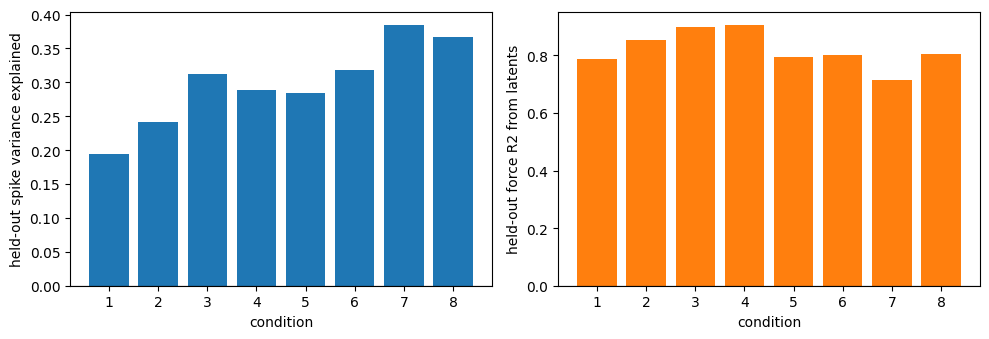

,condition,n_train,n_test,n_bins,final_em_ll,train_ll_per_bin,test_ll_per_bin,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons,force_r2,force_alpha
0,1,30,8,120,-513850.274301,-138.585976,-176.688688,0.193644,0.181764,123,0.789054,1.000000
1,2,28,7,120,-459413.948422,-132.685061,-176.932578,0.241626,0.260271,126,0.853953,1.000000
2,3,30,8,45,-170903.277032,-123.282950,-175.923304,0.311707,0.257112,125,0.897245,3.162278
3,4,30,7,45,-179329.625745,-129.436257,-171.586939,0.288434,0.245421,122,0.905310,1.000000
4,5,29,7,120,-501805.704807,-140.818029,-172.863346,0.283795,0.290963,127,0.793016,1.000000
5,6,34,9,80,-370562.630877,-132.838297,-165.766297,0.318142,0.295219,127,0.800875,1.000000
6,7,49,12,66,-446121.135304,-134.978334,-147.192488,0.384453,0.366708,127,0.714791,1.000000
7,8,59,15,93,-766539.990169,-137.139774,-151.495143,0.366983,0.357108,128,0.803235,0.316228


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(results["condition"], results["spike_var_explained"])
axes[0].set_xlabel("condition")
axes[0].set_ylabel("held-out spike variance explained")
axes[0].axhline(0, color="black", lw=0.8)

axes[1].bar(results["condition"], results["force_r2"], color="tab:orange")
axes[1].set_xlabel("condition")
axes[1].set_ylabel("held-out force R2 from latents")
axes[1].axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

results